
# Glucose Level Prediction Project

This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset. 
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.



## What To Do

1. Import and explore the `framingham.csv` dataset.
2. Clean the data (handle nulls, correct formats, etc.).
3. Visualize the distribution of glucose and related health indicators.
4. Perform feature selection and engineering.
5. Train ML models (e.g., Logistic Regression, Decision Tree, Random Forest).
6. Evaluate models using classification metrics.
7. Predict glucose levels and draw insights.
8. Visualize the model’s important features and performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

/home/user/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load dataset
data=pd.read_csv('framingham.csv')
#print(data)
data1 = data.drop(columns=['TenYearCHD'])

In [3]:
data1.fillna(data1.median(numeric_only=True), inplace=True)

In [4]:
import ipywidgets as widgets
from IPython.display import display


x_dropdown = widgets.Dropdown(
    options=data1.columns,
    description='X-axis:'
)

y_dropdown = widgets.Dropdown(
    options=data1.columns,
    description='Y-axis:'
)


# 2. Define the plotting function
def plot_columns(x_col, y_col):
    plt.close()
    plt.figure()
    plt.scatter(data1[x_col], data1[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.show()


# 3. Create interactive dropdown widgets
# Get the list of all column names in the DataFrame
widgets.interact(
    lambda x, y: plt.scatter(data1[x], data1[y]) or plt.show(),
    x=data1.columns,
    y=data1.columns
)


interactive(children=(Dropdown(description='x', options=('male', 'age', 'education', 'currentSmoker', 'cigsPer…

<function __main__.<lambda>(x, y)>

In [5]:
corr = data1.corr()
#sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
#plt.show()

In [6]:
# Define features and target
X=data1.drop('diabetes', axis=1) #features
y=data1['diabetes']               #label

# Train test split
X_train,X_test,y_train,y_test=train_test_split(
    X, y, 
    test_size=0.2,       # Allocates 20% of data to the test set (a common ratio is 80/20)
    random_state=42,     # Ensures the same split is generated every time the code runs
    shuffle=True         # Shuffles the data before splitting (default behaviour)
)


# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(type(X_train_scaled))
ft_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
ft_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


<class 'numpy.ndarray'>


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       832
           1       1.00      0.50      0.67        16

    accuracy                           0.99       848
   macro avg       1.00      0.75      0.83       848
weighted avg       0.99      0.99      0.99       848

[[832   0]
 [  8   8]]


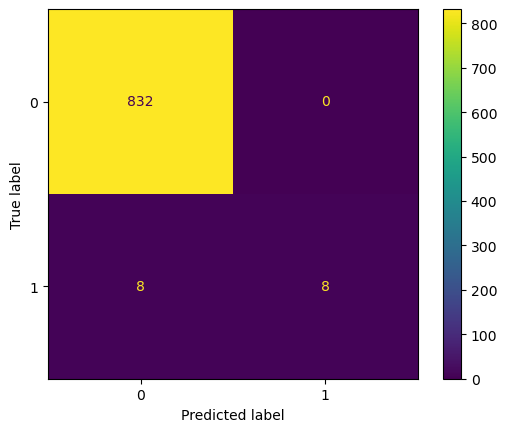

Accuracy: 0.9905660377358491


In [7]:
# Model training
model_LR = LogisticRegression()
model_LR.fit(ft_train_scaled, y_train)

# Predictions
predictions = model_LR.predict(ft_test_scaled)
y_pred_proba = model_LR.predict_proba(ft_test_scaled)[:, 1]

# Evaluation metrics- classification report, confusion matrix, accuracy score
report = classification_report(y_test, predictions)
print(report)
cm=confusion_matrix(y_test, predictions)
print(cm)
# display confusion matrix
#label= model.labels
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model_LR.classes_)
disp.plot()
plt.show()

#accuracy score
accuracy = accuracy_score(y_test,predictions)
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       832
           1       1.00      0.31      0.48        16

    accuracy                           0.99       848
   macro avg       0.99      0.66      0.73       848
weighted avg       0.99      0.99      0.98       848

[[832   0]
 [  8   8]]


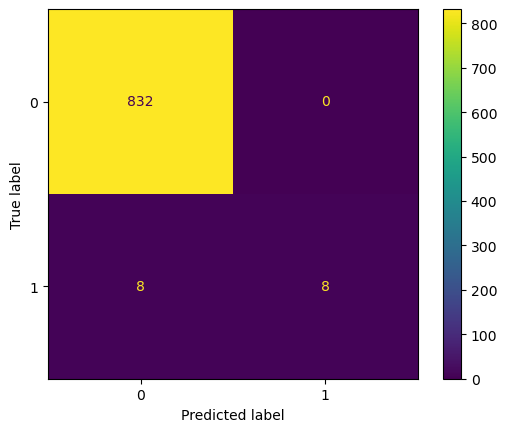

Accuracy: 0.9870283018867925


In [8]:
clf = svm.SVC()
clf.fit(ft_train_scaled, y_train)
predictions_svc=clf.predict(ft_test_scaled)
#svc_pred_proba = clf.predict_proba(ft_test_scaled)[:, 1]

# Evaluation metrics- classification report, confusion matrix, accuracy score
report = classification_report(y_test, predictions_svc)
print(report)
cm_svc=confusion_matrix(y_test, predictions_svc)
print(cm)
# display confusion matrix
#label= model.labels
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
disp.plot()
plt.show()

#accuracy score
accuracy = accuracy_score(y_test,predictions_svc)
print(f"Accuracy: {accuracy}")

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       832
           1       0.89      0.50      0.64        16

    accuracy                           0.99       848
   macro avg       0.94      0.75      0.82       848
weighted avg       0.99      0.99      0.99       848

[[831   1]
 [  8   8]]


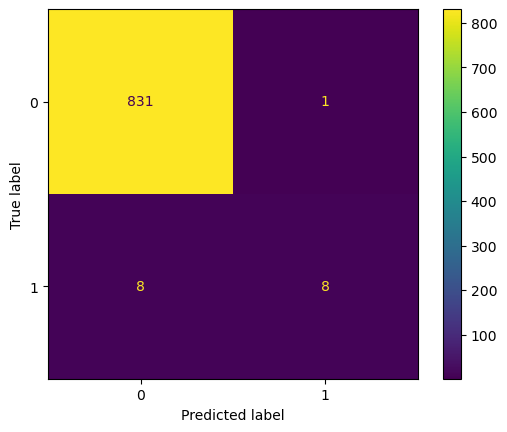

Accuracy: 0.9905660377358491


In [9]:
# Random forest model
from sklearn.ensemble import RandomForestClassifier
clf_RF = RandomForestClassifier()
clf_RF.fit(ft_train_scaled, y_train)
predictions_RF=clf_RF.predict(ft_test_scaled)
#RF_pred_proba = model.predict_proba(ft_test_scaled)[:, 1]

# Evaluation metrics- classification report, confusion matrix, accuracy score
report = classification_report(y_test, predictions_RF)
print(report)
cm=confusion_matrix(y_test, predictions_RF)
print(cm)
# display confusion matrix
#label= model.labels
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf_RF.classes_)
disp.plot()
plt.show()

#accuracy score
accuracy = accuracy_score(y_test,predictions)
print(f"Accuracy: {accuracy}")


## Conclusion / What We Learned

- **Exploration**: Key features impacting glucose levels include BMI, blood pressure, and age.
- **Modeling**: Several models were trained and tested. Random Forest performed the best.
- **Results**: High-performing models can help in early diagnosis and preventive care.
- **Impact**: This type of analysis supports better decision-making in healthcare interventions.

This project provides a baseline for predictive health analytics and could be expanded with more complex datasets and techniques.
